# ERCOT Dallas Covariate-Aware Streaming Forecast with TiRex-2 (Winter/Spring 2026)

This notebook runs zero-shot day-ahead energy forecasting using the **TiRex-2** (`NX-AI/TiRex-2`) foundation model in **True Streaming Mode** (a full covariate-aware streaming setting (historical load target + 8 hourly weather features + calendar features)).

### Streaming Experiment Protocol (Protocol A)
- **Data Source**: `../data/ercot/ercot_dallas_covariate_2026.csv`
- **Model**: `NX-AI/TiRex-2` (xLSTM Architecture)
- **Warmup Lookback**: 512 hours immediately prior to 2026-03-01
- **Streaming Execution**: Memory accumulates continuously across consecutive daily forecasts (512h to 1,256h)
- **Forecast Horizon**: 24 hours (day-ahead, rolling origin daily at 00:00)
- **Evaluation Period**: 2026-03-01 to 2026-03-31
- **Baseline**: Seasonal Naive (168-hour lookback)
- **Probabilistic Calibration**: Nominal 90% Prediction Interval ($q_{0.05}$ to $q_{0.95}$) and 80% Interval ($q_{0.10}$ to $q_{0.90}$)


In [1]:
from __future__ import annotations

import os
import platform
import sys
import time
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# Add src/ to path
for p in [Path.cwd().parent.parent / "src", Path("src"), Path("../src")]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from tirex_streaming_pipeline import TiRexStreamingPipeline

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)


In [2]:
# Load data
candidates = [
    Path("../data/ercot/ercot_dallas_covariate_2026.csv"),
    Path("data/ercot/ercot_dallas_covariate_2026.csv"),
    Path("../" + "../data/ercot/ercot_dallas_covariate_2026.csv"),
]
data_path = next(p for p in candidates if p.exists())
df = pd.read_csv(data_path)

# Prepare dataframe
df["timestamp"] = pd.to_datetime(df["timestamp"])
if "energy" in df.columns:
    df = df.rename(columns={"energy": "target"})
df = df.sort_values("timestamp").reset_index(drop=True)

# Robust hourly resampling
df = df.set_index("timestamp").resample("h").mean().interpolate().reset_index()

covariate_columns = [
    col for col in df.columns 
    if col not in ["timestamp", "target", "item_id"]
]

print(f"Loaded {len(df)} rows of data.")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Covariates identified: {covariate_columns}")
df.head()


Loaded 2160 rows of data.
Date range: 2026-01-01 00:00:00 to 2026-03-31 23:00:00
Covariates identified: ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'dew_point_2m (°C)', 'apparent_temperature (°C)', 'wind_speed_10m (km/h)', 'cloud_cover (%)', 'precipitation (mm)', 'shortwave_radiation (W/m²)', 'day_of_week', 'is_holiday']


,timestamp,target,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),wind_speed_10m (km/h),cloud_cover (%),precipitation (mm),shortwave_radiation (W/m²),day_of_week,is_holiday
0,2026-01-01 00:00:00,11773.493994,10.9,53.0,1.6,7.7,8.9,90.0,0.0,0.0,3.0,1.0
1,2026-01-01 01:00:00,11792.093557,9.4,57.0,1.4,6.3,8.2,98.0,0.0,0.0,3.0,1.0
2,2026-01-01 02:00:00,11764.041621,8.6,61.0,1.5,5.6,7.4,80.0,0.0,0.0,3.0,1.0
3,2026-01-01 03:00:00,11800.767688,8.2,62.0,1.5,5.3,7.3,81.0,0.0,0.0,3.0,1.0
4,2026-01-01 04:00:00,11947.174576,7.7,65.0,1.5,4.8,6.6,47.0,0.0,0.0,3.0,1.0


In [3]:
def resolve_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = resolve_device()
print(f"Loading TiRexStreamingPipeline (NX-AI/TiRex-2) on device='{device}'...")

pipeline = TiRexStreamingPipeline.from_pretrained(
    "NX-AI/TiRex-2",
    device_map=device,
)
print("TiRex-2 Streaming Pipeline successfully loaded.")


Loading TiRexStreamingPipeline (NX-AI/TiRex-2) on device='mps'...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

TiRex-2 Streaming Pipeline successfully loaded.


In [4]:
warmup_length = 512
prediction_length = 24
eval_start = "2026-03-01"
eval_end = "2026-03-31"

print(f"Running True Streaming Forecasting from {eval_start} to {eval_end}...")
t_start = time.perf_counter()

pred_df, step_latencies_ms = pipeline.predict_stream(
    df=df,
    eval_start=eval_start,
    eval_end=eval_end,
    warmup_length=warmup_length,
    prediction_length=prediction_length,
    covariate_cols=covariate_columns,
    quantile_levels=[0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95],
)

total_stream_time = time.perf_counter() - t_start
avg_step_ms = np.mean(step_latencies_ms) if step_latencies_ms else 0.0

print(f"Streaming inference complete in {total_stream_time:.2f}s.")
print(f"Average per-step latency: {avg_step_ms:.1f} ms ({len(step_latencies_ms)} daily steps).")
pred_df.head()


Running True Streaming Forecasting from 2026-03-01 to 2026-03-31...


Streaming inference complete in 32.67s.
Average per-step latency: 1053.0 ms (31 daily steps).


,item_id,timestamp,predictions,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95
0,2026-03-01,2026-03-01 00:00:00,11303.399414,11079.533203,11113.709961,11182.063477,11228.316406,11266.938477,11303.399414,11342.673828,11384.574219,11435.227539,11513.859375,11553.175781
1,2026-03-01,2026-03-01 01:00:00,10698.955078,10366.960938,10418.410156,10521.309570,10587.244141,10644.121094,10698.955078,10755.276367,10817.458008,10895.732422,11026.965820,11092.582031
2,2026-03-01,2026-03-01 02:00:00,10433.892578,9996.029297,10067.808594,10211.367188,10296.562500,10368.820312,10433.892578,10498.997070,10568.836914,10657.617188,10819.237305,10900.046875
3,2026-03-01,2026-03-01 03:00:00,10254.207031,9777.413086,9854.187500,10007.736328,10098.537109,10178.432617,10254.207031,10332.273438,10419.574219,10537.355469,10752.962891,10860.766602
4,2026-03-01,2026-03-01 04:00:00,10299.292969,9767.916016,9859.589844,10042.936523,10140.545898,10222.557617,10299.292969,10380.707031,10472.219727,10598.143555,10828.984375,10944.404297


In [5]:
# Seasonal Naive Baseline: Repeat value from 168 hours ago (1 week)
eval_days = pd.date_range(start="2026-03-01", end="2026-03-31", freq="D")
seasonal_period = 168
baseline_results = []

for target_day in eval_days:
    target_matches = df[df["timestamp"] == target_day].index
    if len(target_matches) == 0:
        continue
    target_idx = target_matches[0]
    target_str = target_day.strftime("%Y-%m-%d")
    
    actual_slice = df.iloc[target_idx : target_idx + prediction_length].copy()
    actual_slice["item_id"] = target_str
    
    lag_start = target_idx - seasonal_period
    lag_end = lag_start + prediction_length
    
    if lag_start >= 0 and lag_end <= len(df):
        baseline_preds = df.iloc[lag_start:lag_end]["target"].values
    else:
        baseline_preds = np.full(prediction_length, np.nan)
        
    baseline_df = actual_slice[["item_id", "timestamp", "target"]].copy()
    baseline_df["baseline_pred"] = baseline_preds
    baseline_results.append(baseline_df)

eval_df = pd.concat(baseline_results).reset_index(drop=True)
eval_df = eval_df.merge(pred_df, on=["item_id", "timestamp"], how="left")
print(f"Merged evaluation dataset: {len(eval_df)} hourly predictions.")
eval_df.head()


Merged evaluation dataset: 744 hourly predictions.


,item_id,timestamp,target,baseline_pred,predictions,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95
0,2026-03-01,2026-03-01 00:00:00,11322.770782,12837.590707,11303.399414,11079.533203,11113.709961,11182.063477,11228.316406,11266.938477,11303.399414,11342.673828,11384.574219,11435.227539,11513.859375,11553.175781
1,2026-03-01,2026-03-01 01:00:00,10784.168787,12706.563592,10698.955078,10366.960938,10418.410156,10521.309570,10587.244141,10644.121094,10698.955078,10755.276367,10817.458008,10895.732422,11026.965820,11092.582031
2,2026-03-01,2026-03-01 02:00:00,10396.522811,12640.107957,10433.892578,9996.029297,10067.808594,10211.367188,10296.562500,10368.820312,10433.892578,10498.997070,10568.836914,10657.617188,10819.237305,10900.046875
3,2026-03-01,2026-03-01 03:00:00,10098.830823,12711.538118,10254.207031,9777.413086,9854.187500,10007.736328,10098.537109,10178.432617,10254.207031,10332.273438,10419.574219,10537.355469,10752.962891,10860.766602
4,2026-03-01,2026-03-01 04:00:00,10044.241726,12997.596510,10299.292969,9767.916016,9859.589844,10042.936523,10140.545898,10222.557617,10299.292969,10380.707031,10472.219727,10598.143555,10828.984375,10944.404297


In [6]:
# In-sample seasonal naive MAE for MASE computation
in_sample_df = df[df["timestamp"] < "2026-03-01"].copy()
if len(in_sample_df) > seasonal_period:
    y_in = in_sample_df["target"].values
    naive_in_sample_mae = np.mean(np.abs(y_in[seasonal_period:] - y_in[:-seasonal_period]))
else:
    naive_in_sample_mae = np.nan

y_true = eval_df["target"].values
y_pred_tirex = eval_df["predictions"].values
y_pred_naive = eval_df["baseline_pred"].values

def compute_metrics(y_t, y_p, naive_mae, q05=None, q10=None, q90=None, q95=None):
    valid = ~np.isnan(y_t) & ~np.isnan(y_p)
    yt, yp = y_t[valid], y_p[valid]
    
    mae = np.mean(np.abs(yt - yp))
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    smape = 100 * np.mean(2 * np.abs(yt - yp) / (np.abs(yt) + np.abs(yp)))
    mase = mae / naive_mae if not np.isnan(naive_mae) else np.nan
    
    cov_80 = np.mean((yt >= q10[valid]) & (yt <= q90[valid])) * 100 if q10 is not None and q90 is not None else np.nan
    cov_90 = np.mean((yt >= q05[valid]) & (yt <= q95[valid])) * 100 if q05 is not None and q95 is not None else np.nan
    
    return mae, rmse, smape, mase, cov_80, cov_90

tirex_metrics = compute_metrics(
    y_true, y_pred_tirex, naive_in_sample_mae,
    q05=eval_df.get("0.05"), q10=eval_df.get("0.1"),
    q90=eval_df.get("0.9"), q95=eval_df.get("0.95"),
)

naive_metrics = compute_metrics(y_true, y_pred_naive, naive_in_sample_mae)

model_label = "TiRex-2 Streaming (Full Covariates)"

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "sMAPE (%)", "MASE", "80% Interval Coverage", "90% Interval Coverage", "Step Latency (ms)"],
    model_label: [
        f"{tirex_metrics[0]:.2f}",
        f"{tirex_metrics[1]:.2f}",
        f"{tirex_metrics[2]:.2f}%",
        f"{tirex_metrics[3]:.3f}",
        f"{tirex_metrics[4]:.2f}%",
        f"{tirex_metrics[5]:.2f}%",
        f"{avg_step_ms:.1f} ms",
    ],
    "Seasonal Naive (7d)": [
        f"{naive_metrics[0]:.2f}",
        f"{naive_metrics[1]:.2f}",
        f"{naive_metrics[2]:.2f}%",
        f"{naive_metrics[3]:.3f}",
        "N/A",
        "N/A",
        "< 0.1 ms",
    ],
})

print(f"\n=== FINAL BENCHMARK METRICS: ERCOT Dallas Covariate-Aware Streaming Forecast with TiRex-2 (Winter/Spring 2026) ===")
display(metrics_df)



=== FINAL BENCHMARK METRICS: ERCOT Dallas Covariate-Aware Streaming Forecast with TiRex-2 (Winter/Spring 2026) ===


,Metric,TiRex-2 Streaming (Full Covariates),Seasonal Naive (7d)
0,MAE,641.92,1565.43
1,RMSE,899.48,2020.57
2,sMAPE (%),4.67%,11.40%
3,MASE,0.267,0.651
4,80% Interval Coverage,79.57%,N/A
5,90% Interval Coverage,85.22%,N/A
6,Step Latency (ms),1053.0 ms,< 0.1 ms


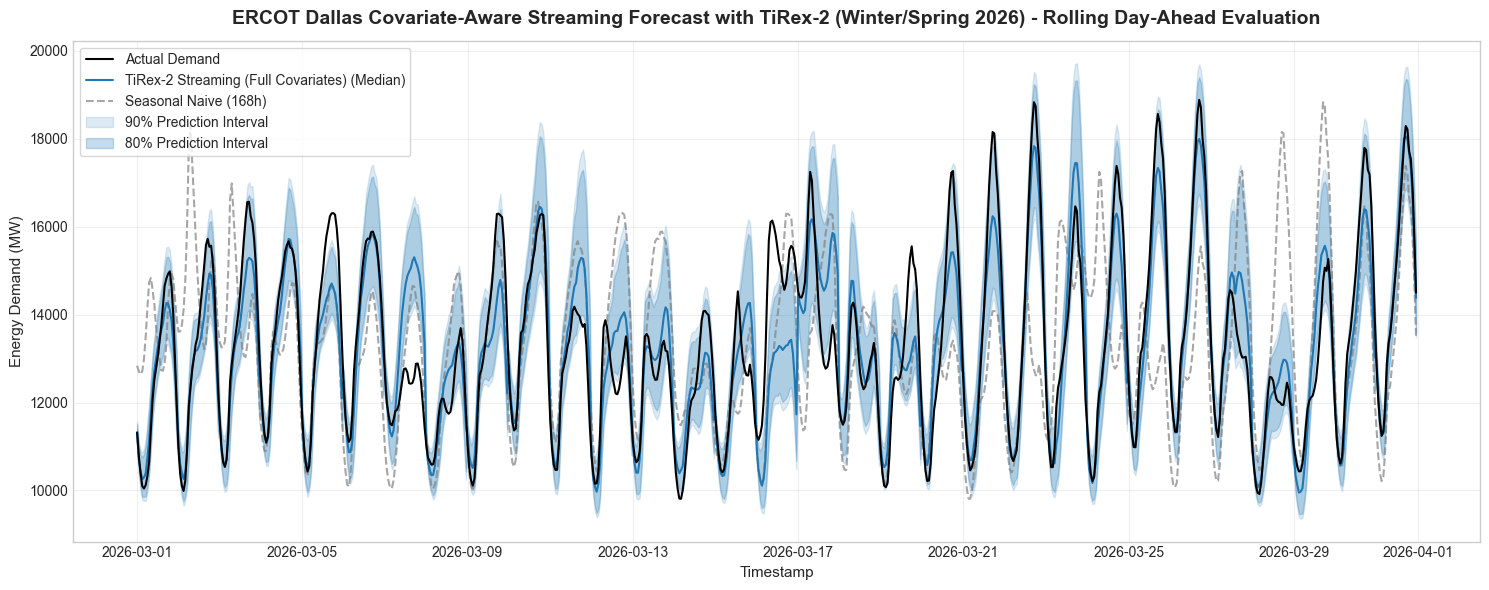

In [7]:
# Plot Day-Ahead Forecasts
plt.figure(figsize=(15, 6), dpi=100)

plt.plot(eval_df["timestamp"], eval_df["target"], label="Actual Demand", color="black", linewidth=1.5, zorder=4)
plt.plot(eval_df["timestamp"], eval_df["predictions"], label="TiRex-2 Streaming (Full Covariates) (Median)", color="#1f77b4", linewidth=1.5, zorder=3)
plt.plot(eval_df["timestamp"], eval_df["baseline_pred"], label="Seasonal Naive (168h)", color="gray", linestyle="--", alpha=0.7, zorder=2)

if "0.05" in eval_df.columns and "0.95" in eval_df.columns:
    plt.fill_between(
        eval_df["timestamp"],
        eval_df["0.05"],
        eval_df["0.95"],
        color="#1f77b4",
        alpha=0.15,
        label="90% Prediction Interval",
        zorder=1,
    )

if "0.1" in eval_df.columns and "0.9" in eval_df.columns:
    plt.fill_between(
        eval_df["timestamp"],
        eval_df["0.1"],
        eval_df["0.9"],
        color="#1f77b4",
        alpha=0.25,
        label="80% Prediction Interval",
        zorder=1,
    )

plt.title(f"ERCOT Dallas Covariate-Aware Streaming Forecast with TiRex-2 (Winter/Spring 2026) - Rolling Day-Ahead Evaluation", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Timestamp", fontsize=11)
plt.ylabel(f"Energy Demand (MW)", fontsize=11)
plt.legend(loc="upper left", frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
